In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# def spring(start, end, nodes, width):
#     """!
#     Return a list of points corresponding to a spring.

#     @param r1 (array-like) The (x, y) coordinates of the first endpoint.
#     @param r2 (array-like) The (x, y) coordinates of the second endpoint.
#     @param nodes (int) The number of spring "nodes" or coils.
#     @param width (int or float) The diameter of the spring.
#     @return An array of x coordinates and an array of y coordinates.
#     """

#     # Check that nodes is at least 1.
#     nodes = max(int(nodes), 1)

#     # Convert to numpy array to account for inputs of different types/shapes.
#     start, end = np.array(start).reshape((2,)), np.array(end).reshape((2,))

#     # If both points are coincident, return the x and y coords of one of them.
#     if (start == end).all():
#         return start[0], start[1]

#     # Calculate length of spring (distance between endpoints).
#     length = np.linalg.norm(np.subtract(end, start))

#     # Calculate unit vectors tangent (u_t) and normal (u_t) to spring.
#     u_t = np.subtract(end, start) / length
#     u_n = np.array([[0, -1], [1, 0]]).dot(u_t)

#     # Initialize array of x (row 0) and y (row 1) coords of the nodes+2 points.
#     spring_coords = np.zeros((2, nodes + 2))
#     spring_coords[:,0], spring_coords[:,-1] = start, end

#     # Check that length is not greater than the total length the spring
#     # can extend (otherwise, math domain error will result), and compute the
#     # normal distance from the centerline of the spring.
#     normal_dist = math.sqrt(max(0, width**2 - (length**2 / nodes**2))) / 2

#     # Compute the coordinates of each point (each node).
#     for i in range(1, nodes + 1):
#         spring_coords[:,i] = (
#             start
#             + ((length * (2 * i - 1) * u_t) / (2 * nodes))
#             + (normal_dist * (-1)**i * u_n))

#     return spring_coords[0,:], spring_coords[1,:]

In [3]:

def spring(start, end, coils=10, width=0.5, nodes=500, ):
    """
    Generates a 2D spring that looks 3D by projecting a helix.
    """
    start = np.array(start)
    end = np.array(end)
    vector = end - start
    length = np.linalg.norm(vector)
    unit_vector = vector / length
    
    # Perpendicular vector for the width (normal)
    normal = np.array([-unit_vector[1], unit_vector[0]])

    # Parametric variable t from 0 to 1
    t = np.linspace(0, 1, nodes)
    
    # Linear progression along the main axis
    line_points = start[np.newaxis, :] + t[:, np.newaxis] * vector
    
    # 3D-to-2D projection logic:
    # We use a sine wave for the 'width' displacement
    # We add a slight phase-shifted cosine to the 'length' to create the loop-back
    theta = 2 * np.pi * coils * t
    
    # Longitudinal offset (this creates the 'overlap' by moving points back and forth)
    # The 0.1 factor controls how 'flat' or 'round' the loops look
    longitudinal_offset = (width * 0.3) * np.cos(theta)
    
    # Lateral offset (the actual width of the spring)
    lateral_offset = width * np.sin(theta)
    
    # Combine everything
    spring_x = line_points[:, 0] + longitudinal_offset * unit_vector[0] + lateral_offset * normal[0]
    spring_y = line_points[:, 1] + longitudinal_offset * unit_vector[1] + lateral_offset * normal[1]
    
    return spring_x, spring_y

In [31]:
def draw_potential(ax, origin, x_len, y_len):
    """
    Plots a potential well (parabola) labeled with kappa^2/2 on an existing axis.
    
    Parameters:
    ax: matplotlib.axes.Axes object to plot on.
    origin: tuple (x0, y0) representing the center/vertex of the potential.
    x_len: float, the total horizontal span of the x-axis arrow.
    y_len: float, the total vertical height of the y-axis arrow.
    """
    x0, y0 = origin
    
    # Calculate parabola points centered at the origin
    # We plot it up to ~80% of the arrow length for visual clarity
    x_span = x_len * 0.4
    x_vals = np.linspace(x0 - x_span, x0 + x_span, 100)
    
    # Define a scaling factor so the parabola fits within the y_len
    # y = a(x - x0)^2 + y0
    a = (y_len * 0.7) / (x_span**2)
    y_vals = a * (x_vals - x0)**2 + y0
    
    # 1. Plot the potential curve
    ax.plot(x_vals, y_vals, color='tab:blue', linewidth=2)
    
    # 2. Draw the x-axis arrow (horizontal)
    ax.annotate('', xy=(x0 + x_len/2, y0), xytext=(x0 - x_len/2, y0),
                arrowprops=dict(arrowstyle='->', color='tab:blue', lw=1.5))
    
    # 3. Draw the y-axis arrow (vertical)
    ax.annotate('', xy=(x0, y0 + y_len), xytext=(x0, y0 - 0.35 * y_len),
                arrowprops=dict(arrowstyle='->', color='tab:blue', lw=1.5))
    
    # 4. Add the kappa^2/2 label
    ax.text(x0 + x_len * 0.15, y0 + y_len * 0.6, r'$\frac{\kappa^2}{2}$', fontsize=20, color="tab:blue")

# Example Usage:
# fig, ax = plt.subplots()
# draw_potential(ax, origin=(5, 2), x_len=4, y_len=6)
# plt.show()

In [32]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'stix', 
    'font.size': 17              
})

(np.float64(-0.9), np.float64(2.9), np.float64(-1.5), np.float64(1.5))

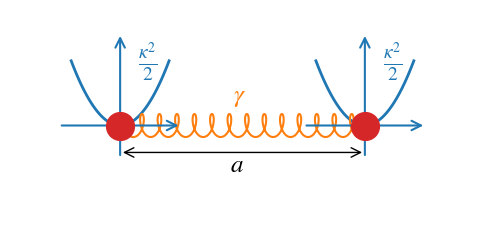

In [40]:
site1_coordx = 0
site1_coordy = 0 
site2_coordx = 2
site2_coordy = 0 
sp_len = 0.3
# sp1x,sp1y = spring((site1_coordx-sp_len,site1_coordy), (site1_coordx, site1_coordy), 12, 0.2, )
# sp2x,sp2y = spring((site2_coordx-sp_len,site2_coordy), (site2_coordx, site2_coordy), 12, 0.2, )
sp3x,sp3y = spring((site1_coordx, site1_coordx), (site2_coordx, site2_coordy), 14, 0.15)

fig, ax = plt.subplots(figsize=(6,3))
# plt.text(site1_coordx-sp_len/1.2,site1_coordy+sp_len/1.5,r"$\kappa$",fontsize="18",color="tab:blue")
# plt.text(site2_coordx-sp_len/1.2,site2_coordy+sp_len/1.5,r"$\kappa$",fontsize="18",color="tab:blue")
plt.text((site1_coordx+site2_coordx)/2-sp_len/4,(site1_coordy+site2_coordy)/2+sp_len,r"$\gamma$",fontsize="18",color="tab:orange")
plt.text(.9,-.6,r"$a$",fontsize="18",color="black")
ax.annotate("",
            xy=(0., -0.35), xycoords='data',
            xytext=(2, -.35), textcoords='data',
            arrowprops=dict(arrowstyle="<->"))
plt.scatter(site1_coordx, site1_coordy, s=400, color="tab:red",zorder=20)
plt.scatter(site2_coordx, site2_coordy, s=400, color="tab:red",zorder=20)
# plt.plot(sp1x,sp1y,color="tab:blue")
# plt.plot(sp2x,sp2y,color="tab:blue")
draw_potential(ax, (site1_coordx,site1_coordy),1,1.2)
draw_potential(ax, (site2_coordx,site2_coordy),1,1.2)
plt.plot(sp3x,sp3y,color="tab:orange")
plt.xlim(-.9,2.9)
plt.ylim(-1.5,1.5)
plt.axis('off')


<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
C:\Users\xylin\AppData\Local\Temp\ipykernel_6900\814189175.py:13: SyntaxWarning: invalid escape sequence '\o'
  ax.set_ylabel('$\omega$ [meV]', )


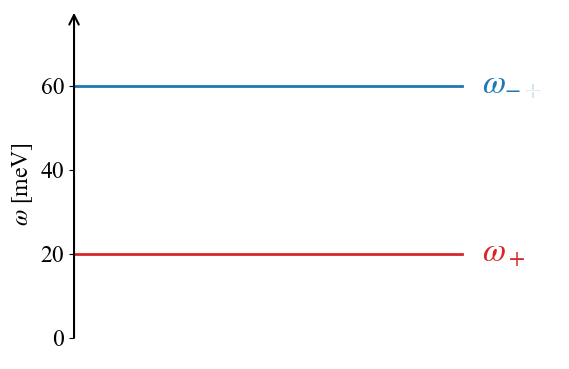

In [131]:
ffig, ax = plt.subplots(figsize=(6, 4))
# Plot horizontal lines
ax.axhline(y=60,xmin=0,xmax=0.8, color='tab:blue', linestyle='-', linewidth=2)
ax.text(.8, 60, r'$\omega_{- +}$', va='center', ha='left', color='tab:blue',fontsize=24 ,)
ax.text(.882, 60.07, r'$_{+}$', va='center', ha='left', color='white',fontsize=24 ,alpha=1,zorder=200)
 
ax.axhline(y=20, xmin=0,xmax=0.8,color='tab:red', linestyle='-', linewidth=2)
ax.text(.8, 20, r'$\omega_+$', va='center', ha='left', color='tab:red', fontsize=24 )

# Set axis limits and labels
ax.set_ylim(-5, 78)
ax.set_xlim(0, .95)
ax.set_ylabel('$\omega$ [meV]', )

# Only one vertical y-axis. Hide the top and right spines.
ax.spines['top'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['right'].set_visible(False)
# Hide x-axis ticks
ax.set_xticks([])
# ax.set_yticks([20,40,60],[20,40,60])
ax.annotate('', xy=(0, 78), xytext=(0, -0.6),
            arrowprops=dict(arrowstyle="->", color='black', lw=1.5),
            xycoords='data', textcoords='data')
# Title
# ax.set_title('Energy Levels', fontsize=14)

# Adjust layout
plt.tight_layout()

